# Notebook 10 — Custom Dataset Preparation for Transfer Learning

This notebook prepares the custom domain-specific dataset from `customDataset/` folder for **transfer learning** using the backbone pretrained in Notebook 02.

**Key improvements over Notebook 03:**
- ✓ Loads hand bounding boxes from JSON files (`*_arm_boxes.json`)
- ✓ Crops depth frames using hand bounding boxes (like Notebook 01)
- ✓ Resizes cropped frames to 64×64 for backbone input
- ✓ Creates temporal sliding windows (T=16, stride=4)
- ✓ Stratified clip-level train/val/test split
- ✓ Labels: 0=Idle (stationary), 1=Reaching (handReaching), 2=Other (waving hands)

**Workflow:**
1. Scan folder structure (stationary, handReaching, other)
2. Load and parse JSON bounding boxes
3. Crop and resize depth frames to 64×64
4. Create temporal windows for backbone input
5. Create clip-level train/val/test split
6. Save prepared arrays for transfer learning

## Table of Contents
1. [Environment & Imports](#1)
2. [Scan Custom Dataset & Load Bounding Boxes](#2)
3. [Crop & Resize Depth Sequences](#3)
4. [Create Temporal Windows](#4)
5. [Train/Val/Test Split (Clip-Level)](#5)
6. [Save Prepared Data](#6)
7. [QA Visualization](#7)
8. [Summary](#8)

---
## 1. Environment & Imports <a id='1'></a>

In [8]:
import sys
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm.notebook import tqdm
import torch

# Make src/ importable
SRC = Path('..') / 'src'
if str(SRC.resolve()) not in sys.path:
    sys.path.insert(0, str(SRC.resolve()))

from config import PROC_DIR, DEPTH_RESIZE, DEPTH_MAX_MM, WINDOW_T, STRIDE
from preprocess_depth import _expand_bbox, crop_and_resize_frame

# Custom dataset root
CUSTOM_DATASET_ROOT = Path('..') / 'customDataset'
CUSTOM_PROC_DIR = PROC_DIR / 'custom_transfer'
CUSTOM_PROC_DIR.mkdir(exist_ok=True, parents=True)

print(f'Custom dataset root: {CUSTOM_DATASET_ROOT}')
print(f'Processing output: {CUSTOM_PROC_DIR}')
print(f'Depth params: resize={DEPTH_RESIZE}, max_mm={DEPTH_MAX_MM}, window_t={WINDOW_T}, stride={STRIDE}')

# Label mapping for transfer learning
LABEL_MAP = {
    'stationary': 0,      # Idle
    'handReaching': 1,    # Reaching
    'other': 2            # Other (waving hands)
}
LABEL_NAMES = {0: 'Idle', 1: 'Reaching', 2: 'Other'}

print(f'\nLabel mapping:')
for folder, label in LABEL_MAP.items():
    print(f'  {folder:15} → {label} ({LABEL_NAMES[label]})')


Custom dataset root: ..\customDataset
Processing output: D:\course\comp4471\comp4471-project\dataset\processed\custom_transfer
Depth params: resize=64, max_mm=3000.0, window_t=16, stride=4

Label mapping:
  stationary      → 0 (Idle)
  handReaching    → 1 (Reaching)
  other           → 2 (Other)


---
## 2. Scan Custom Dataset <a id='2'></a>

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# SCAN CUSTOM DATASET & LOAD BOUNDING BOXES
# ══════════════════════════════════════════════════════════════════════════════

def load_bounding_boxes_from_json(clip_dir):
    """
    Load hand bounding boxes from *_arm_boxes.json file.
    Returns dict: {frame_filename: [x, y, w, h]}
    """
    json_files = list(clip_dir.glob('*_arm_boxes.json'))
    if not json_files:
        return {}
    
    json_file = json_files[0]
    with open(json_file, 'r') as f:
        data = json.load(f)
    
    bboxes = {}
    for annotation in data.get('annotations', []):
        frame_name = annotation['frame']
        hand_box = annotation.get('hand_box', None)
        if hand_box:
            # hand_box is [x1, y1, x2, y2] (corner format)
            # Convert to [x, y, w, h] (SHREC format)
            x1, y1, x2, y2 = hand_box
            x, y, w, h = x1, y1, x2 - x1, y2 - y1
            bboxes[frame_name] = [x, y, w, h]
    
    return bboxes

def get_clip_label(clip_dir):
    """
    Load activity label from general_information.txt.
    Returns: 0=stationary, 1=handReaching, 2=other (waving hands)
    Returns None if file not found or label unrecognized.
    """
    info_file = clip_dir / 'general_information.txt'
    if not info_file.exists():
        return None
    
    try:
        with open(info_file, 'r') as f:
            label_str = f.read().strip().lower()
        
        # Map to integer label
        if label_str == 'stationary':
            return 0
        elif label_str == 'handreaching':
            return 1
        elif label_str in ['other', 'waving', 'waving hands']:
            return 2
        else:
            print(f'⚠ Unrecognized label in {clip_dir.name}: "{label_str}"')
            return None
    except Exception as e:
        print(f'⚠ Error reading label from {clip_dir}: {e}')
        return None

# ══════════════════════════════════════════════════════════════════════════════
# SCAN FLAT FOLDER STRUCTURE
# ══════════════════════════════════════════════════════════════════════════════

# Scan all clip folders directly under customDataset/
clips_info = []  # List of (intention_label, clip_path, n_frames, bboxes_dict)

print(f'Scanning {CUSTOM_DATASET_ROOT} for clip folders...\n')

# List all subdirectories (one per clip)
clip_dirs = sorted([d for d in CUSTOM_DATASET_ROOT.iterdir() if d.is_dir() and d.name != 'cropped_depth_maps'])

for clip_dir in clip_dirs:
    # Get label from general_information.txt
    label = get_clip_label(clip_dir)
    if label is None:
        print(f'  Skipping {clip_dir.name}: no valid label')
        continue
    
    # Count PNG files
    pngs = sorted([f for f in clip_dir.glob('*Depth*.png')])
    if len(pngs) == 0:
        print(f'  Skipping {clip_dir.name}: no depth PNGs found')
        continue
    
    # Load bounding boxes
    bboxes_dict = load_bounding_boxes_from_json(clip_dir)
    clips_info.append((label, clip_dir, len(pngs), bboxes_dict))
    
    label_name = LABEL_NAMES[label]
    print(f'  {clip_dir.name:20} {len(pngs):3d} frames  label={label_name:10} bbox_count={len(bboxes_dict):3d}')

print(f'\n{"="*70}')
print(f'Total clips found: {len(clips_info)}')

# Summary by category
for label, name in LABEL_NAMES.items():
    count = sum(1 for l, _, _, _ in clips_info if l == label)
    total_frames = sum(n for l, _, n, _ in clips_info if l == label)
    if count > 0:
        print(f'  {name:10} {count:3d} clips, {total_frames:6d} frames total')


Scanning ..\customDataset for clip folders...

  0504_0007_80          80 frames  label=Idle       bbox_count= 80
  0504_0140_90          77 frames  label=Reaching   bbox_count= 77
  0504_0153_90          70 frames  label=Other      bbox_count= 70
  0504_0204_90          90 frames  label=Other      bbox_count= 90
  0504_0206_90          69 frames  label=Other      bbox_count= 69
  0504_0208_90          70 frames  label=Reaching   bbox_count= 70
  0504_2017_90          69 frames  label=Reaching   bbox_count= 46
  0504_2019_90          90 frames  label=Reaching   bbox_count= 79
  0504_2020_90          90 frames  label=Reaching   bbox_count= 79
  0504_2021_90          90 frames  label=Reaching   bbox_count= 80
  0504_2022_90          90 frames  label=Idle       bbox_count= 31
  0504_2023_90          90 frames  label=Other      bbox_count= 83
  0504_2026_90          90 frames  label=Reaching   bbox_count= 18
  0504_2027_90          90 frames  label=Reaching   bbox_count= 54
  0504_2033_90 

---
## 3. Process Depth Sequences <a id='3'></a>

For each clip, load PNG frames, crop/resize, and create sliding windows.

In [12]:
def load_custom_depth_sequence_cropped(clip_path, bboxes_dict, size=DEPTH_RESIZE):
    """
    Load and process depth sequence from custom dataset.
    Uses hand bounding boxes from JSON to crop each frame.
    
    Args:
        clip_path: Path to clip folder
        bboxes_dict: Dict mapping frame filename → [x, y, w, h]
        size: Target resize dimension (default 64)
    
    Returns:
        (N, 64, 64) float32 array [0,1] normalized, or None if clip too short
    """
    pngs = sorted([f for f in clip_path.glob('*Depth*.png')])
    if len(pngs) == 0:
        return None
    
    frames = []
    for png_path in pngs:
        # Load raw depth
        depth_raw = np.array(Image.open(png_path), dtype=np.float32)
        # depth_raw is (480, 640) in mm
        
        # Try to get bounding box from JSON
        bbox_entry = bboxes_dict.get(png_path.name, None)
        
        if bbox_entry is not None:
            # Use provided bounding box
            bbox = np.array(bbox_entry, dtype=int)  # [x, y, w, h]
            try:
                crop_resized = crop_and_resize_frame(depth_raw, bbox, size=size)
                frames.append(crop_resized)
            except Exception as e:
                print(f'  ⚠ Error cropping {png_path.name}: {e}')
                continue
        else:
            # Fallback: find hand ROI by non-zero pixels
            nonzero = np.where(depth_raw > 0)
            if len(nonzero[0]) == 0:
                # Blank frame, skip
                continue
            
            y_min, y_max = nonzero[0].min(), nonzero[0].max()
            x_min, x_max = nonzero[1].min(), nonzero[1].max()
            
            # Expand bbox slightly
            h = y_max - y_min + 1
            w = x_max - x_min + 1
            margin = max(h, w) * 0.1
            x_min = max(0, int(x_min - margin))
            y_min = max(0, int(y_min - margin))
            x_max = min(640, int(x_max + margin))
            y_max = min(480, int(y_max + margin))
            
            # Crop and normalize
            crop = depth_raw[y_min:y_max, x_min:x_max]
            crop = np.clip(crop, 0, DEPTH_MAX_MM) / DEPTH_MAX_MM
            
            # Resize to target size
            crop_pil = Image.fromarray((crop * 255).astype(np.uint8))
            crop_resized = np.array(crop_pil.resize((size, size), Image.BILINEAR), dtype=np.float32) / 255.0
            
            frames.append(crop_resized)
    
    if len(frames) < WINDOW_T:
        return None
    
    return np.array(frames, dtype=np.float32)

# ══════════════════════════════════════════════════════════════════════════════
# PROCESS ALL CLIPS
# ══════════════════════════════════════════════════════════════════════════════

all_depth_sequences = []  # List of (label, clip_path, depth_seq_array)
valid_clip_count = 0

print('\nProcessing clips with bounding box cropping...')
for label, clip_path, n_frames, bboxes_dict in tqdm(clips_info, desc='Loading & cropping depth sequences'):
    depth_seq = load_custom_depth_sequence_cropped(clip_path, bboxes_dict)
    if depth_seq is not None:
        all_depth_sequences.append((label, clip_path, depth_seq))
        valid_clip_count += 1

print(f'\n{"="*70}')
print(f'Successfully processed: {valid_clip_count}/{len(clips_info)} clips')

# Verify shapes
if len(all_depth_sequences) > 0:
    _, _, sample_seq = all_depth_sequences[0]
    print(f'Sample depth sequence shape: {sample_seq.shape} (frames × height × width)')



Processing clips with bounding box cropping...


Loading & cropping depth sequences:   0%|          | 0/15 [00:00<?, ?it/s]


Successfully processed: 15/15 clips
Sample depth sequence shape: (80, 64, 64) (frames × height × width)


---
## 4. Generate Pseudo-Labels for Branch B <a id='4'></a>

Since custom dataset has no skeleton annotations, we generate pseudo-labels using a simple heuristic:
- Compute hand centroid from depth map (weighted by pixel values)
- Estimate hand orientation from PCA of non-zero pixels
- Store as (22, 3) pseudo-skeleton (palm centroid repeated, orientation as normal)


In [13]:
---
## 4. Create Temporal Windows <a id='4'></a>

Generate sliding windows (T=16, stride=4) from each depth sequence.
This creates the temporal context needed for the backbone to learn motion patterns.

SyntaxError: invalid syntax (4257515307.py, line 1)

---
## 5. Create Train/Val/Test Split <a id='5'></a>

Split at the **clip level** to prevent frame leakage.

In [14]:
from sklearn.model_selection import StratifiedShuffleSplit

# ══════════════════════════════════════════════════════════════════════════════
# CLIP-LEVEL TRAIN/VAL/TEST SPLIT (NO FRAME LEAKAGE)
# ══════════════════════════════════════════════════════════════════════════════

# Extract labels for stratification
clip_labels = np.array([label for label, _, _ in all_depth_sequences])
n_clips = len(clip_labels)

print(f'Creating stratified clip-level split from {n_clips} clips...')

# Split 1: train 70%, temp (val+test) 30%
sss_1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_indices, temp_indices = next(sss_1.split(np.arange(n_clips), clip_labels))

# Split 2: split temp into val 50%, test 50% (15% each of total)
temp_labels = clip_labels[temp_indices]
class_counts = np.bincount(temp_labels)

# Handle case where a rare class appears only once in temp split
if len(class_counts) < len(LABEL_NAMES) or np.min(class_counts[class_counts > 0]) < 2:
    print('⚠ Rare class detected; using unstratified val/test split')
    rng = np.random.default_rng(42)
    shuffled_temp = rng.permutation(temp_indices)
    half = len(shuffled_temp) // 2
    val_indices = shuffled_temp[:half]
    test_indices = shuffled_temp[half:]
else:
    sss_2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
    val_indices_in_temp, test_indices_in_temp = next(sss_2.split(np.arange(len(temp_indices)), temp_labels))
    val_indices = temp_indices[val_indices_in_temp]
    test_indices = temp_indices[test_indices_in_temp]

print(f'\nClip-level split:')
print(f'  Train: {len(train_indices)} clips')
print(f'  Val:   {len(val_indices)} clips')
print(f'  Test:  {len(test_indices)} clips')

# Check class distribution in each split
print(f'\nClass distribution per split:')
for split_name, indices in [('Train', train_indices), ('Val', val_indices), ('Test', test_indices)]:
    labels_unique, counts = np.unique(clip_labels[indices], return_counts=True)
    print(f'\n  {split_name}:')
    for lbl, cnt in zip(labels_unique, counts):
        pct = 100 * cnt / len(indices)
        print(f'    {LABEL_NAMES[lbl]:10} {cnt:3d} clips ({pct:5.1f}%)')


Creating stratified clip-level split from 15 clips...
⚠ Rare class detected; using unstratified val/test split

Clip-level split:
  Train: 10 clips
  Val:   2 clips
  Test:  3 clips

Class distribution per split:

  Train:
    Idle         1 clips ( 10.0%)
    Reaching     6 clips ( 60.0%)
    Other        3 clips ( 30.0%)

  Val:
    Idle         1 clips ( 50.0%)
    Reaching     1 clips ( 50.0%)

  Test:
    Reaching     2 clips ( 66.7%)
    Other        1 clips ( 33.3%)


---
## 6. Create Windowed Sequences & Save <a id='6'></a>

Generate sliding windows and save for both branches.

In [16]:
# ---
## 5. Train/Val/Test Split (Clip-Level) <a id='5'></a>

# Split at the **clip level** to prevent frame leakage between train/val/test.

# ---
## 6. Save Prepared Data <a id='6'></a>

# Create sliding windows and save for transfer learning with the pretrained backbone.

def create_windowed_sequences(depth_sequences, indices):
    """
    Create sliding windows from a subset of clips.
    Returns: (windows_depth, window_labels)
    
    Each window is (T, 64, 64) depth frames.
    """
    windows_depth = []
    windows_labels = []
    
    for idx in indices:
        label, _, depth_seq = all_depth_sequences[idx]
        # depth_seq is (N_frames, 64, 64)
        
        n_frames = len(depth_seq)
        if n_frames < WINDOW_T:
            continue
        
        # Create sliding windows with stride
        for start in range(0, n_frames - WINDOW_T + 1, STRIDE):
            end = start + WINDOW_T
            if end > n_frames:
                break
            
            window = depth_seq[start:end]  # (T, 64, 64)
            windows_depth.append(window)
            windows_labels.append(label)
    
    return (
        np.array(windows_depth, dtype=np.float32),   # (M, T, 64, 64)
        np.array(windows_labels, dtype=np.int64),    # (M,)
    )

# ══════════════════════════════════════════════════════════════════════════════
# CREATE WINDOWS FOR EACH SPLIT
# ══════════════════════════════════════════════════════════════════════════════

print('\nCreating sliding windows (T=16, stride=4)...')
train_depth, train_labels = create_windowed_sequences(all_depth_sequences, train_indices)
val_depth, val_labels = create_windowed_sequences(all_depth_sequences, val_indices)
test_depth, test_labels = create_windowed_sequences(all_depth_sequences, test_indices)

print(f'\n{"="*70}')
print(f'Windowed sequences created:')
print(f'  Train: {train_depth.shape}  ({len(train_labels)} windows)')
print(f'  Val:   {val_depth.shape}  ({len(val_labels)} windows)')
print(f'  Test:  {test_depth.shape}  ({len(test_labels)} windows)')
print(f'  Total: {len(train_labels) + len(val_labels) + len(test_labels)} windows')



Creating sliding windows (T=16, stride=4)...

Windowed sequences created:
  Train: (172, 16, 64, 64)  (172 windows)
  Val:   (36, 16, 64, 64)  (36 windows)
  Test:  (52, 16, 64, 64)  (52 windows)
  Total: 260 windows


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# SAVE PREPARED DATA FOR TRANSFER LEARNING
# ══════════════════════════════════════════════════════════════════════════════

# Save train/val/test splits
# Format: X = (M, T, 64, 64) depth windows, y = (M,) labels

np.savez(
    CUSTOM_PROC_DIR / 'custom_transfer_train.npz',
    X=train_depth, y=train_labels
)
np.savez(
    CUSTOM_PROC_DIR / 'custom_transfer_val.npz',
    X=val_depth, y=val_labels
)
np.savez(
    CUSTOM_PROC_DIR / 'custom_transfer_test.npz',
    X=test_depth, y=test_labels
)

# Save metadata
metadata = {
    'label_map': LABEL_MAP,
    'label_names': LABEL_NAMES,
    'window_size': WINDOW_T,
    'window_stride': STRIDE,
    'depth_size': DEPTH_RESIZE,
    'depth_max_mm': DEPTH_MAX_MM,
    'n_train_clips': len(train_indices),
    'n_val_clips': len(val_indices),
    'n_test_clips': len(test_indices),
    'n_train_windows': len(train_labels),
    'n_val_windows': len(val_labels),
    'n_test_windows': len(test_labels),
}

with open(CUSTOM_PROC_DIR / 'metadata.json', 'w') as f:
    # Convert numpy types to Python types for JSON serialization
    metadata_serializable = {k: int(v) if isinstance(v, (np.integer, np.floating)) else v 
                            for k, v in metadata.items()}
    json.dump(metadata_serializable, f, indent=2)

print(f'\n{"="*70}')
print(f'✓ Saved training data:')
print(f'    custom_transfer_train.npz  ({train_depth.nbytes / 1e6:.1f} MB)')
print(f'    custom_transfer_val.npz    ({val_depth.nbytes / 1e6:.1f} MB)')
print(f'    custom_transfer_test.npz   ({test_depth.nbytes / 1e6:.1f} MB)')
print(f'    metadata.json')
print(f'\nLocation: {CUSTOM_PROC_DIR}')



✓ Saved training data:
    custom_transfer_train.npz  (45.1 MB)
    custom_transfer_val.npz    (9.4 MB)
    custom_transfer_test.npz   (13.6 MB)
    metadata.json

Location: D:\course\comp4471\comp4471-project\dataset\processed\custom_transfer


---
## 7. QA Visualization <a id='7'></a>

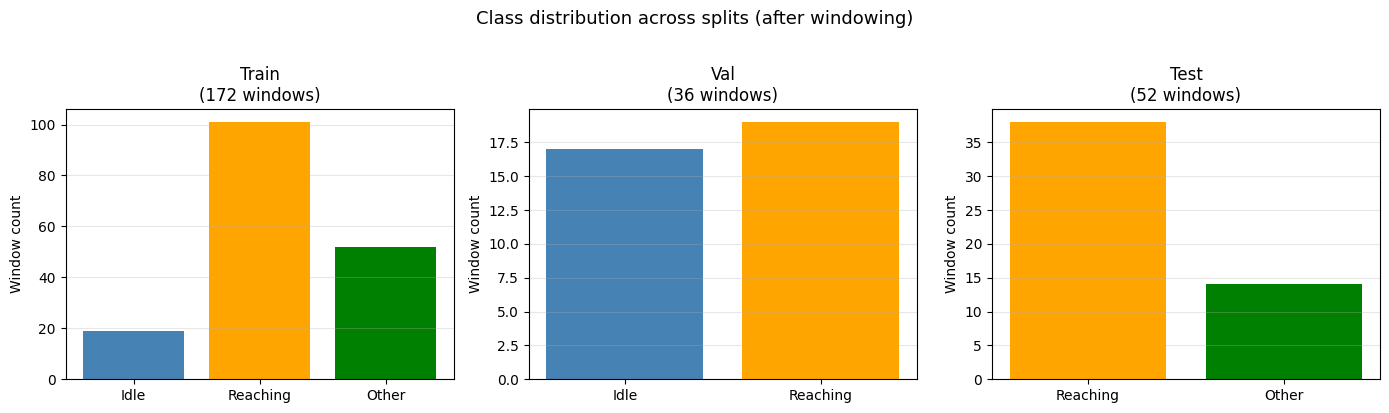

✓ Saved class_distribution.png


In [19]:
# ---
## 7. QA Visualization <a id='7'></a>

# Check class distribution after windowing
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (data, name) in zip(axes, [
    (train_labels, f'Train\n({len(train_labels)} windows)'),
    (val_labels, f'Val\n({len(val_labels)} windows)'),
    (test_labels, f'Test\n({len(test_labels)} windows)')
]):
    labels_unique, counts = np.unique(data, return_counts=True)
    colors = ['steelblue', 'orange', 'green']
    ax.bar([LABEL_NAMES[lbl] for lbl in labels_unique], counts, color=[colors[lbl] for lbl in labels_unique])
    ax.set_ylabel('Window count')
    ax.set_title(name)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Class distribution across splits (after windowing)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(CUSTOM_PROC_DIR / 'class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Saved class_distribution.png')


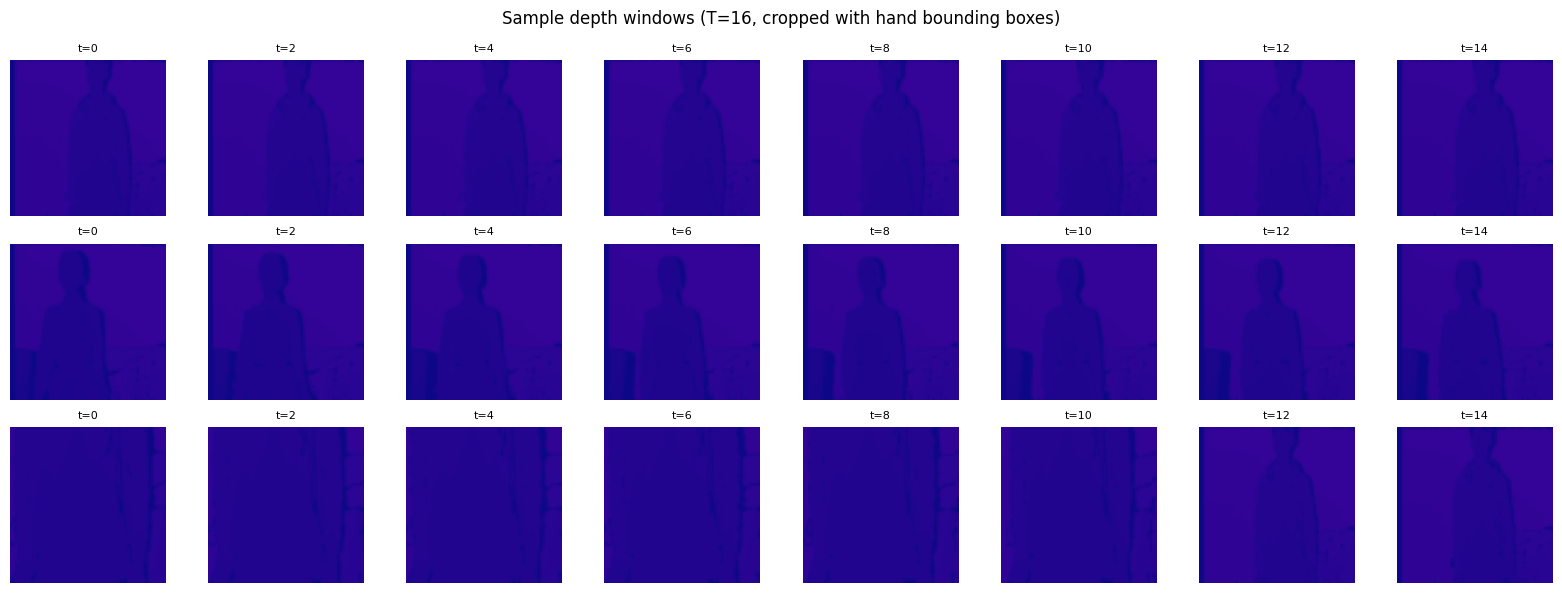

✓ Saved sample_windows.png


In [20]:
# Visualize sample windows from each class
fig, axes = plt.subplots(3, 8, figsize=(16, 6))

for row, (label, name) in enumerate([(0, 'Idle'), (1, 'Reaching'), (2, 'Other')]):
    # Find first window of this class in training set
    indices_of_class = np.where(train_labels == label)[0]
    if len(indices_of_class) > 0:
        win_idx = indices_of_class[0]
        window = train_depth[win_idx]  # (T, 64, 64)
        
        # Show 8 evenly-spaced frames from this window
        for col in range(8):
            frame_idx = min(col * (len(window) // 8), len(window) - 1)
            ax = axes[row, col]
            ax.imshow(window[frame_idx], cmap='plasma', vmin=0, vmax=1)
            ax.set_title(f't={frame_idx}', fontsize=8)
            ax.axis('off')
        
        axes[row, 0].set_ylabel(name, fontsize=11, fontweight='bold')
    else:
        # No samples of this class
        for col in range(8):
            axes[row, col].text(0.5, 0.5, f'No {name} samples', 
                               ha='center', va='center', transform=axes[row, col].transAxes)
            axes[row, col].axis('off')

fig.suptitle('Sample depth windows (T=16, cropped with hand bounding boxes)', fontsize=12, y=0.98)
plt.tight_layout()
plt.savefig(CUSTOM_PROC_DIR / 'sample_windows.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Saved sample_windows.png')


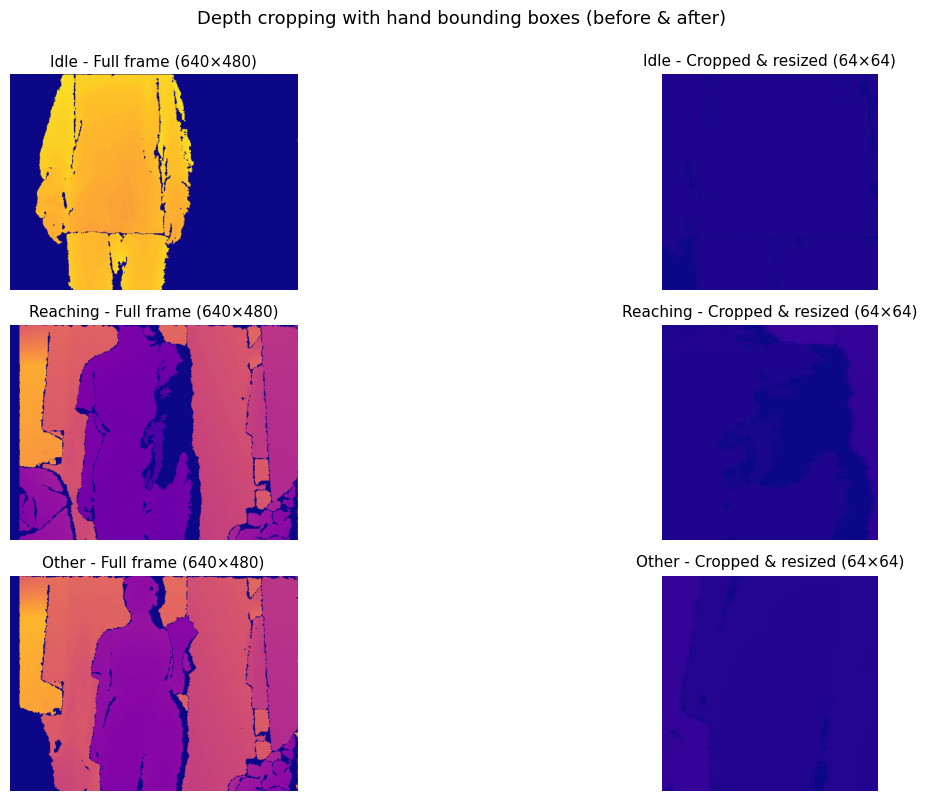

✓ Saved cropping_example.png


In [21]:
# Demonstrate bounding box cropping: before & after
# Pick a few samples to show the improvement from cropping

fig = plt.figure(figsize=(16, 8))

# Sample 3 clips from different classes
for row_idx, (label, name) in enumerate([(0, 'Idle'), (1, 'Reaching'), (2, 'Other')]):
    clip_indices = [i for i, (l, _, _) in enumerate(all_depth_sequences) if l == label]
    if len(clip_indices) == 0:
        continue
    
    clip_idx = clip_indices[0]  # Pick first clip of this class
    label_c, clip_path_c, depth_seq_c = all_depth_sequences[clip_idx]
    
    # Pick middle frame
    mid_frame_idx = len(depth_seq_c) // 2
    cropped_frame = depth_seq_c[mid_frame_idx]  # (64, 64)
    
    # Load original uncropped frame to show difference
    pngs = sorted([f for f in clip_path_c.glob('*Depth*.png')])
    if len(pngs) > mid_frame_idx:
        uncropped = np.array(Image.open(pngs[mid_frame_idx]), dtype=np.float32)
        uncropped_norm = np.clip(uncropped, 0, DEPTH_MAX_MM) / DEPTH_MAX_MM
    else:
        uncropped_norm = np.zeros((480, 640))
    
    # Plot side by side
    ax1 = plt.subplot(3, 2, row_idx * 2 + 1)
    ax1.imshow(uncropped_norm, cmap='plasma')
    ax1.set_title(f'{name} - Full frame (640×480)', fontsize=11)
    ax1.axis('off')
    
    ax2 = plt.subplot(3, 2, row_idx * 2 + 2)
    ax2.imshow(cropped_frame, cmap='plasma', vmin=0, vmax=1)
    ax2.set_title(f'{name} - Cropped & resized (64×64)', fontsize=11)
    ax2.axis('off')

fig.suptitle('Depth cropping with hand bounding boxes (before & after)', fontsize=13, y=0.995)
plt.tight_layout()
plt.savefig(CUSTOM_PROC_DIR / 'cropping_example.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Saved cropping_example.png')


In [23]:
# ---
# ## 8. Summary <a id='8'></a>

# Summary
print('\n' + '='*70)
print('CUSTOM DATASET PREPARATION FOR TRANSFER LEARNING — COMPLETE')
print('='*70)
print(f'\n✓ Processed {valid_clip_count} clips with hand bounding box cropping')
print(f'✓ Created temporal windows (T={WINDOW_T}, stride={STRIDE})')
print(f'✓ Stratified train/val/test split at clip level (no frame leakage)')
print(f'\nDataset summary:')
print(f'  Train windows: {len(train_labels):6d}')
print(f'  Val windows:   {len(val_labels):6d}')
print(f'  Test windows:  {len(test_labels):6d}')
print(f'  Total:         {len(train_labels) + len(val_labels) + len(test_labels):6d}')

print(f'\nClass balance (train set):')
train_labels_unique, train_counts = np.unique(train_labels, return_counts=True)
for lbl, cnt in zip(train_labels_unique, train_counts):
    pct = 100 * cnt / len(train_labels)
    print(f'  {LABEL_NAMES[lbl]:10} {cnt:6d} windows ({pct:5.1f}%)')

print(f'\nData specifications:')
print(f'  Window shape:        (T={WINDOW_T}, H={DEPTH_RESIZE}, W={DEPTH_RESIZE})')
print(f'  Depth value range:   [0, 1] normalized')
print(f'  Bounding box method: Hand boxes from JSON annotations')
print(f'  Labels:              {LABEL_NAMES}')

print(f'\nSaved files:')
print(f'  {CUSTOM_PROC_DIR}/custom_transfer_train.npz')
print(f'  {CUSTOM_PROC_DIR}/custom_transfer_val.npz')
print(f'  {CUSTOM_PROC_DIR}/custom_transfer_test.npz')
print(f'  {CUSTOM_PROC_DIR}/metadata.json')
print(f'  {CUSTOM_PROC_DIR}/class_distribution.png')
print(f'  {CUSTOM_PROC_DIR}/sample_windows.png')
print(f'  {CUSTOM_PROC_DIR}/cropping_example.png')

print(f'\nNext steps for transfer learning:')
print(f'  1. Load pretrained backbone from Notebook 02:')
print(f'     dataset/processed/pretrained_depth_backbone.pth')
print(f'  2. Attach custom classification head (3 classes)')
print(f'  3. Fine-tune on custom dataset (train/val split above)')
print(f'  4. Evaluate on test split')
print('='*70)



CUSTOM DATASET PREPARATION FOR TRANSFER LEARNING — COMPLETE

✓ Processed 15 clips with hand bounding box cropping
✓ Created temporal windows (T=16, stride=4)
✓ Stratified train/val/test split at clip level (no frame leakage)

Dataset summary:
  Train windows:    172
  Val windows:       36
  Test windows:      52
  Total:            260

Class balance (train set):
  Idle           19 windows ( 11.0%)
  Reaching      101 windows ( 58.7%)
  Other          52 windows ( 30.2%)

Data specifications:
  Window shape:        (T=16, H=64, W=64)
  Depth value range:   [0, 1] normalized
  Bounding box method: Hand boxes from JSON annotations
  Labels:              {0: 'Idle', 1: 'Reaching', 2: 'Other'}

Saved files:
  D:\course\comp4471\comp4471-project\dataset\processed\custom_transfer/custom_transfer_train.npz
  D:\course\comp4471\comp4471-project\dataset\processed\custom_transfer/custom_transfer_val.npz
  D:\course\comp4471\comp4471-project\dataset\processed\custom_transfer/custom_transfer_te